#  Portfolio Optimization — Markowitz Multi-Asset (2019–2024)
**Objetivo:** Construir y optimizar un portafolio institucional en dos capas usando Modern Portfolio Theory (MPT).

**Flujo de trabajo:**
```
yfinance (Web Scraping) → SQLite3 (almacenamiento) → EDA → Capa 1: Equity Optimization → Capa 2: Multi-Asset → Risk Analysis
```

---
## Tabla de contenidos
1. [Web Scraping con yfinance](#1)
2. [Almacenamiento en SQLite3](#2)
3. [EDA — Retornos, Volatilidad y Correlaciones](#3)
4. [Capa 1 — Optimización del Portafolio de Acciones](#4)
5. [Capa 2 — Optimización Multi-Asset](#5)
6. [Risk Analysis del Portafolio Final](#6)
7. [Conclusiones](#7)


## 1. Web Scraping con yfinance <a id='1'></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import sqlite3
import yfinance as yf
from scipy.optimize import minimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('outputs', exist_ok=True)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')


### 1.1 Definición del universo de activos

Organizamos los activos en dos capas:
- **Capa 1 — Equity:** 16 acciones del S&P 500 diversificadas por sector
- **Capa 2 — Alternativos:** ETFs de crypto, commodities y bonos


In [19]:
# Universo de activos
EQUITIES = {
    'AAPL':  'Technology',  'MSFT':  'Technology',
    'GOOGL': 'Technology',  'NVDA':  'Technology',
    'META':  'Technology',  'JPM':   'Finance',
    'GS':    'Finance',     'BAC':   'Finance',
    'JNJ':   'Health',      'PFE':   'Health',
    'XOM':   'Energy',      'CVX':   'Energy',
    'AMZN':  'Consumer',    'WMT':   'Consumer',
    'TSLA':  'Consumer',    'UNH':   'Health' 
}

ALTERNATIVES = {
    'GLD':  'Gold',
    'SLV':  'Silver',
    'TLT':  'Bonds (Long)',
    'USO':  'Oil',
    'IBIT': 'Bitcoin ETF'
}

ALL_TICKERS = list(EQUITIES.keys()) + list(ALTERNATIVES.keys())

print("=== Universo de activos ===")
print(f"Acciones (Capa 1):     {len(EQUITIES)} tickers")
print(f"Alternativos (Capa 2): {len(ALTERNATIVES)} tickers")
print(f"Total:                 {len(ALL_TICKERS)} tickers")


=== Universo de activos ===
Acciones (Capa 1):     16 tickers
Alternativos (Capa 2): 5 tickers
Total:                 21 tickers


In [20]:
# ── Web Scraping con yfinance ─────────────────────────────────────────────────
print("Descargando datos históricos 2019-2024...")

raw = yf.download(
    ALL_TICKERS,
    start='2019-01-01',
    end='2024-12-31',
    auto_adjust=True,
    progress=False
)['Close']

# IBIT solo disponible desde ene 2024 — separar períodos
prices_equity = raw[list(EQUITIES.keys())].dropna()
prices_all    = raw.dropna()  # solo desde ene 2024

print(f"   Datos descargados")
print(f"   Equity (2019-2024):     {prices_equity.shape[0]:,} días × {prices_equity.shape[1]} activos")
print(f"   Multi-asset (2024):     {prices_all.shape[0]:,} días × {prices_all.shape[1]} activos")
print(f"   Rango equity:           {prices_equity.index[0].date()} → {prices_equity.index[-1].date()}")
print(f"   Rango multi-asset:      {prices_all.index[0].date()} → {prices_all.index[-1].date()}")


Descargando datos históricos 2019-2024...
   Datos descargados
   Equity (2019-2024):     1,509 días × 16 activos
   Multi-asset (2024):     244 días × 21 activos
   Rango equity:           2019-01-02 → 2024-12-30
   Rango multi-asset:      2024-01-11 → 2024-12-30


## 2. Almacenamiento en SQLite3 <a id='2'></a>

In [21]:
# ── Crear base de datos SQLite3 ───────────────────────────────────────────────
DB_PATH = 'data/portfolio.db'

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# Tabla 1: precios diarios
prices_long = raw.reset_index().melt(
    id_vars='Date', var_name='ticker', value_name='price')
prices_long['Date'] = prices_long['Date'].astype(str)
prices_long.to_sql('daily_prices', conn, if_exists='replace', index=False)

# Tabla 2: metadata de activos
meta = []
for ticker, sector in EQUITIES.items():
    meta.append({'ticker': ticker, 'sector': sector, 'asset_class': 'Equity'})
for ticker, desc in ALTERNATIVES.items():
    meta.append({'ticker': ticker, 'sector': desc, 'asset_class': 'Alternative'})
pd.DataFrame(meta).to_sql('asset_metadata', conn, if_exists='replace', index=False)

# Tabla 3: retornos logarítmicos
returns_equity = np.log(prices_equity / prices_equity.shift(1)).dropna()
ret_long = returns_equity.reset_index().melt(
    id_vars='Date', var_name='ticker', value_name='log_return')
ret_long['Date'] = ret_long['Date'].astype(str)
ret_long.to_sql('log_returns', conn, if_exists='replace', index=False)

conn.commit()

print("   Base de datos creada:", DB_PATH)
print(f"   Tabla daily_prices:    {pd.read_sql('SELECT COUNT(*) as n FROM daily_prices', conn).iloc[0,0]:,} filas")
print(f"   Tabla asset_metadata:  {pd.read_sql('SELECT COUNT(*) as n FROM asset_metadata', conn).iloc[0,0]:,} filas")
print(f"   Tabla log_returns:     {pd.read_sql('SELECT COUNT(*) as n FROM log_returns', conn).iloc[0,0]:,} filas")


   Base de datos creada: data/portfolio.db
   Tabla daily_prices:    31,689 filas
   Tabla asset_metadata:  21 filas
   Tabla log_returns:     24,128 filas


In [23]:
# ── Consultas SQL para verificar ─────────────────────────────────────────────
print("=== Top 10 activos por retorno promedio diario ===")
query = '''
    SELECT
        r.ticker,
        m.sector,
        m.asset_class,
        ROUND(AVG(r.log_return) * 252 * 100, 2) AS annual_return_pct,
        ROUND(
            SQRT(AVG(r.log_return * r.log_return) - AVG(r.log_return) * AVG(r.log_return))
            * SQRT(252) * 100, 2
        ) AS annual_vol_pct
    FROM log_returns r
    JOIN asset_metadata m ON r.ticker = m.ticker
    GROUP BY r.ticker, m.sector, m.asset_class
    ORDER BY annual_return_pct DESC
    LIMIT 10
'''
result = pd.read_sql(query, conn)
print(result.to_string(index=False))


=== Top 10 activos por retorno promedio diario ===
ticker     sector asset_class  annual_return_pct  annual_vol_pct
  NVDA Technology      Equity              61.93           51.59
  TSLA   Consumer      Equity              50.22           64.32
  AAPL Technology      Equity              31.76           30.84
  MSFT Technology      Equity              24.98           29.02
  META Technology      Equity              24.66           42.94
    GS    Finance      Equity              22.51           31.64
 GOOGL Technology      Equity              21.59           31.22
   WMT   Consumer      Equity              19.44           21.42
  AMZN   Consumer      Equity              17.65           34.12
   JPM    Finance      Equity              17.63           30.58


## 3. EDA — Retornos, Volatilidad y Correlaciones <a id='3'></a>

In [24]:
# Retornos y volatilidad anualizados
returns_equity = np.log(prices_equity / prices_equity.shift(1)).dropna()
ann_returns = returns_equity.mean() * 252 * 100
ann_vols    = returns_equity.std()  * np.sqrt(252) * 100
sharpe      = (returns_equity.mean() * 252) / (returns_equity.std() * np.sqrt(252))

summary = pd.DataFrame({
    'Retorno Anual (%)': ann_returns.round(2),
    'Volatilidad Anual (%)': ann_vols.round(2),
    'Sharpe Ratio': sharpe.round(3),
    'Sector': pd.Series(EQUITIES)
}).sort_values('Retorno Anual (%)', ascending=False)

print("=== Métricas por acción (2019-2024) ===")
print(summary.to_string())


=== Métricas por acción (2019-2024) ===
       Retorno Anual (%)  Volatilidad Anual (%)  Sharpe Ratio      Sector
NVDA               61.93                  51.60         1.200  Technology
TSLA               50.22                  64.34         0.780    Consumer
AAPL               31.76                  30.85         1.029  Technology
MSFT               24.98                  29.03         0.860  Technology
META               24.66                  42.96         0.574  Technology
GS                 22.51                  31.65         0.711     Finance
GOOGL              21.59                  31.23         0.691  Technology
WMT                19.44                  21.43         0.907    Consumer
AMZN               17.65                  34.13         0.517    Consumer
JPM                17.63                  30.59         0.576     Finance
UNH                13.79                  29.23         0.472      Health
BAC                11.89                  33.89         0.351     Financ

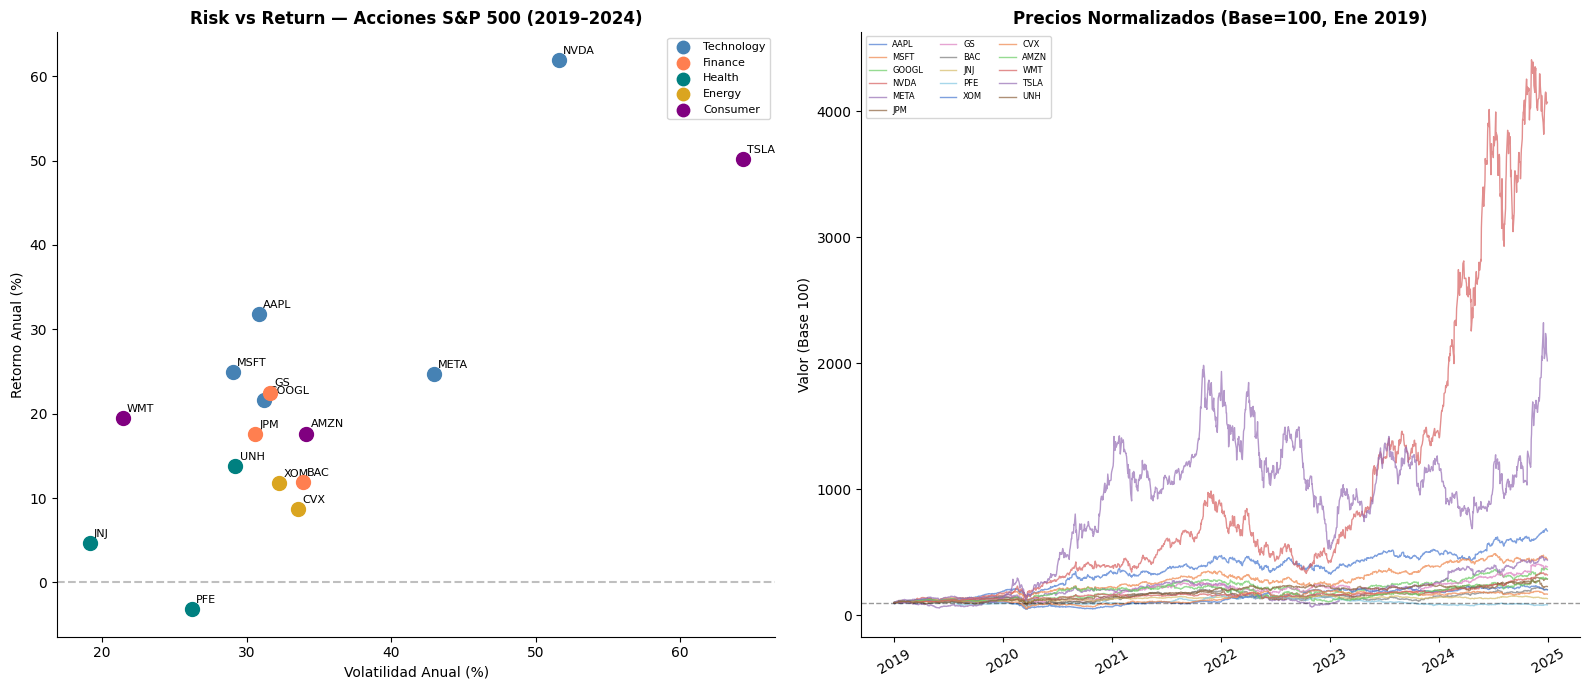

 NVDA dominó el período con +2,000% de retorno — outlier extremo.
 Tecnología lidera en retorno pero también en volatilidad.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter retorno vs volatilidad — Risk/Return tradeoff
colors_sector = {'Technology':'steelblue','Finance':'coral','Health':'teal',
                 'Energy':'goldenrod','Consumer':'purple'}

for ticker in EQUITIES:
    sector = EQUITIES[ticker]
    axes[0].scatter(ann_vols[ticker], ann_returns[ticker],
                    color=colors_sector[sector], s=100, zorder=5)
    axes[0].annotate(ticker, (ann_vols[ticker], ann_returns[ticker]),
                     fontsize=8, ha='left', va='bottom',
                     xytext=(3, 3), textcoords='offset points')

# Leyenda manual
for sector, color in colors_sector.items():
    axes[0].scatter([], [], color=color, label=sector, s=80)

axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Risk vs Return — Acciones S&P 500 (2019–2024)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Volatilidad Anual (%)')
axes[0].set_ylabel('Retorno Anual (%)')
axes[0].legend(fontsize=8)

# Precios normalizados (base 100)
normalized = (prices_equity / prices_equity.iloc[0] * 100)
for ticker in EQUITIES:
    axes[1].plot(normalized.index, normalized[ticker],
                 linewidth=1, alpha=0.7, label=ticker)

axes[1].axhline(100, color='black', linestyle='--', alpha=0.4, linewidth=1)
axes[1].set_title('Precios Normalizados (Base=100, Ene 2019)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Valor (Base 100)')
axes[1].legend(fontsize=6, ncol=3, loc='upper left')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/01_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()
print(" NVDA dominó el período con +2,000% de retorno — outlier extremo.")
print(" Tecnología lidera en retorno pero también en volatilidad.")


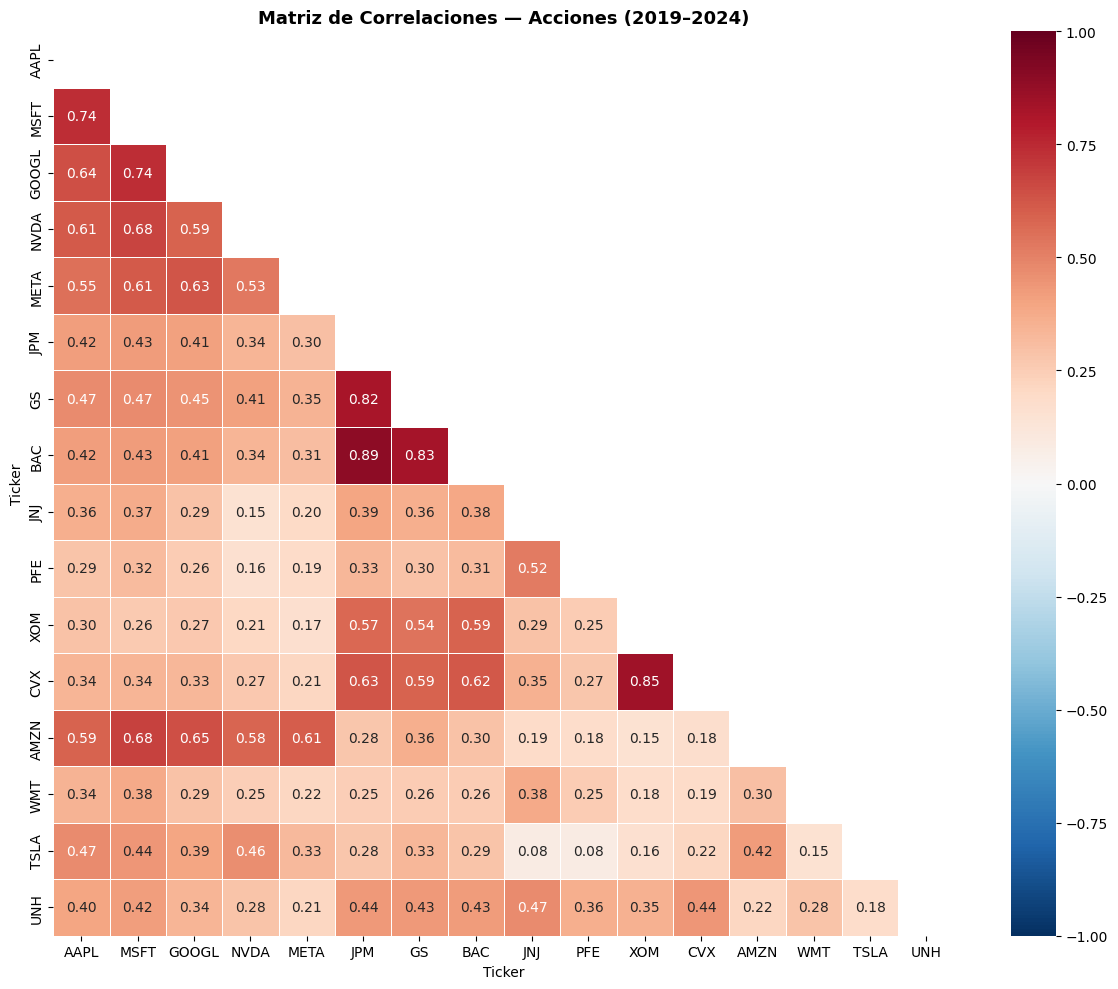

 Tech stocks (AAPL, MSFT, GOOGL, META) altamente correlacionadas — menor diversificación entre ellas.
 Energía (XOM, CVX) y Finance (JPM, BAC, GS) forman sus propios clusters.


In [26]:
# Heatmap de correlaciones
corr = returns_equity.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlaciones — Acciones (2019–2024)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Tech stocks (AAPL, MSFT, GOOGL, META) altamente correlacionadas — menor diversificación entre ellas.")
print(" Energía (XOM, CVX) y Finance (JPM, BAC, GS) forman sus propios clusters.")


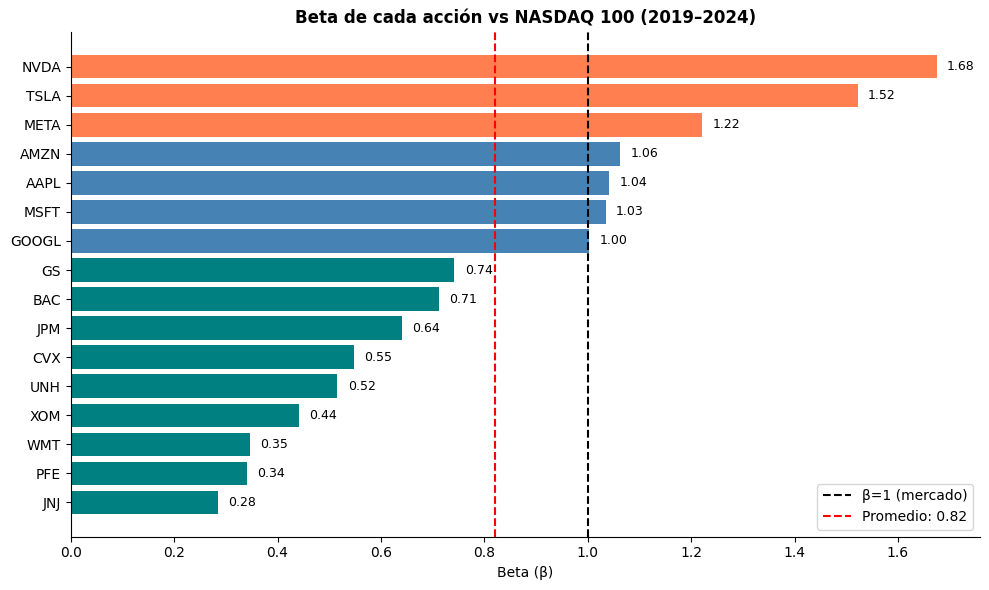


=== Beta por sector (promedio) ===
Sector
Technology    1.195
Consumer      0.977
Finance       0.698
Energy        0.495
Health        0.381
Name: Beta, dtype: float64

 Beta > 1.2 (coral): más volátil que el NASDAQ 100 — mayor riesgo sistemático
 Beta < 0.8 (teal): activos defensivos — menor sensibilidad al mercado
 Nota: usamos NASDAQ 100 en lugar de S&P 500 para evitar sesgo de endogeneidad
   con las Magnificent 7 que representan ~30% del índice.


In [27]:
# ── Beta respecto al NASDAQ 100 ───────────────────────────────────────────────
ndx = yf.download('^NDX', start='2019-01-01', end='2024-12-31',
                  auto_adjust=True, progress=False)['Close']
ndx_returns = np.log(ndx / ndx.shift(1)).dropna()

# Alinear fechas
common = returns_equity.index.intersection(ndx_returns.index)
ret_eq_aligned  = returns_equity.loc[common]
ndx_ret_aligned = ndx_returns.loc[common]

betas = {}
for ticker in EQUITIES:
    cov = ret_eq_aligned[ticker].cov(ndx_ret_aligned.squeeze())
    var = ndx_ret_aligned.var().squeeze()
    betas[ticker] = round(cov / var, 3)

beta_df = pd.Series(betas, name='Beta').sort_values(ascending=True)
beta_df = pd.DataFrame(beta_df).reset_index()
beta_df.columns = ['Ticker', 'Beta']
beta_df['Sector'] = beta_df['Ticker'].map(EQUITIES)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['coral' if b > 1.2 else 'steelblue' if b > 0.8 else 'teal'
          for b in beta_df['Beta']]
ax.barh(beta_df['Ticker'], beta_df['Beta'], color=colors)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5,
           label='β=1 (mercado)')
ax.axvline(beta_df['Beta'].mean(), color='red', linestyle='--',
           label=f'Promedio: {beta_df["Beta"].mean():.2f}')
ax.set_title('Beta de cada acción vs NASDAQ 100 (2019–2024)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Beta (β)')
ax.legend()

for bar, val in zip(ax.patches, beta_df['Beta']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/02b_beta_nasdaq.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Beta por sector (promedio) ===")
print(beta_df.groupby('Sector')['Beta'].mean().sort_values(ascending=False).round(3))
print("\n Beta > 1.2 (coral): más volátil que el NASDAQ 100 — mayor riesgo sistemático")
print(" Beta < 0.8 (teal): activos defensivos — menor sensibilidad al mercado")
print(" Nota: usamos NASDAQ 100 en lugar de S&P 500 para evitar sesgo de endogeneidad")
print("   con las Magnificent 7 que representan ~30% del índice.")

## 4. Capa 1 — Optimización del Portafolio de Acciones <a id='4'></a>

Aplicamos **Modern Portfolio Theory (MPT)** de Markowitz para encontrar:
- **Portafolio de Máximo Sharpe Ratio** — mejor retorno ajustado por riesgo
- **Portafolio de Mínima Varianza** — menor riesgo posible
- **Frontera Eficiente** — conjunto de portafolios óptimos

**Restricciones:** pesos entre 0% y 40% por activo, suma = 100% (no ventas en corto)


In [28]:
# ── Funciones de optimización ─────────────────────────────────────────────────
RF_RATE = 0.04  # Tasa libre de riesgo anual

mu  = returns_equity.mean() * 252       # retornos anualizados
cov = returns_equity.cov() * 252        # covarianza anualizada
n   = len(EQUITIES)

def portfolio_metrics(weights):
    ret = np.dot(weights, mu)
    vol = np.sqrt(weights @ cov @ weights)
    sharpe = (ret - RF_RATE) / vol
    return ret, vol, sharpe

def neg_sharpe(weights):
    return -portfolio_metrics(weights)[2]

def portfolio_vol(weights):
    return portfolio_metrics(weights)[1]

# Restricciones y bounds
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds = tuple((0.0, 0.40) for _ in range(n))
w0 = np.array([1/n] * n)

# ── Máximo Sharpe ─────────────────────────────────────────────────────────────
result_sharpe = minimize(neg_sharpe, w0, method='SLSQP',
                          bounds=bounds, constraints=constraints)
w_sharpe = result_sharpe.x
ret_s, vol_s, sharpe_s = portfolio_metrics(w_sharpe)

# ── Mínima Varianza ───────────────────────────────────────────────────────────
result_minvar = minimize(portfolio_vol, w0, method='SLSQP',
                          bounds=bounds, constraints=constraints)
w_minvar = result_minvar.x
ret_m, vol_m, sharpe_m = portfolio_metrics(w_minvar)

print("=" * 55)
print("   CAPA 1 — PORTAFOLIOS ÓPTIMOS DE ACCIONES")
print("=" * 55)
print(f"{'Métrica':<25} {'Max Sharpe':>14} {'Min Varianza':>14}")
print("-" * 55)
print(f"{'Retorno anual':<25} {ret_s*100:>13.2f}% {ret_m*100:>13.2f}%")
print(f"{'Volatilidad anual':<25} {vol_s*100:>13.2f}% {vol_m*100:>13.2f}%")
print(f"{'Sharpe Ratio':<25} {sharpe_s:>14.3f} {sharpe_m:>14.3f}")
print("=" * 55)


   CAPA 1 — PORTAFOLIOS ÓPTIMOS DE ACCIONES
Métrica                       Max Sharpe   Min Varianza
-------------------------------------------------------
Retorno anual                     39.34%         10.75%
Volatilidad anual                 28.67%         15.82%
Sharpe Ratio                       1.233          0.427


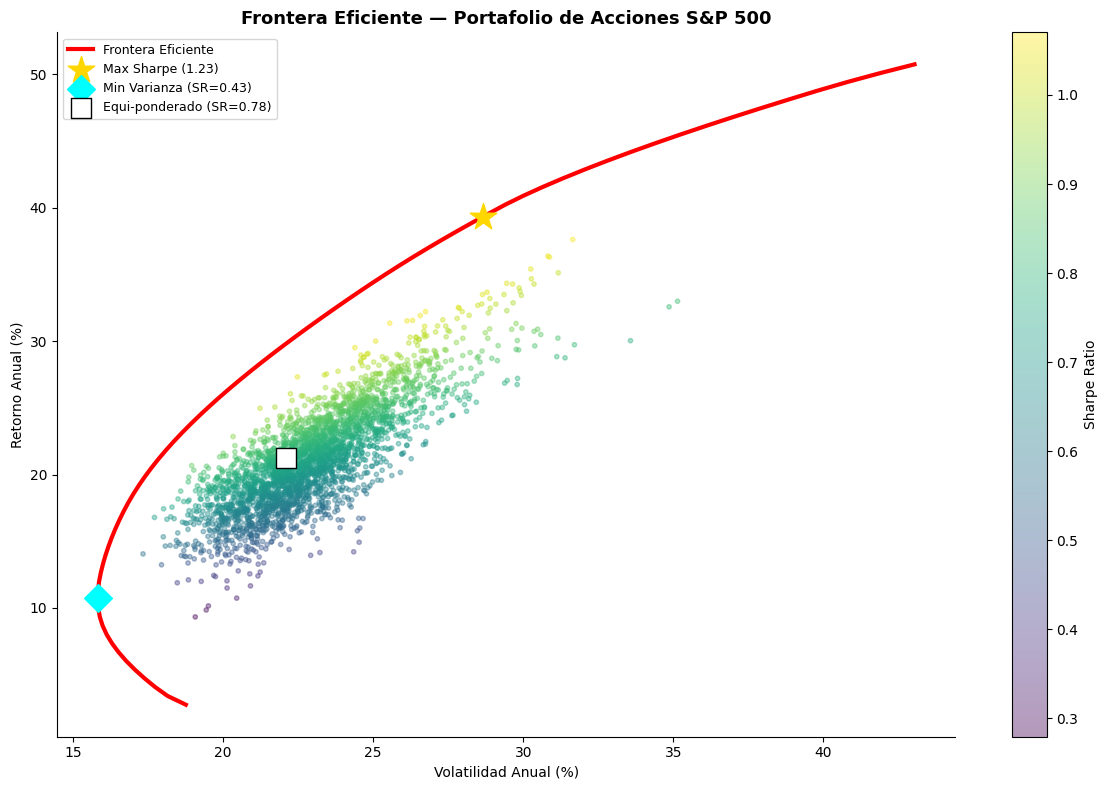

In [29]:
# ── Frontera Eficiente ────────────────────────────────────────────────────────
target_returns = np.linspace(mu.min(), mu.max(), 100)
frontier_vols, frontier_rets = [], []

for target in target_returns:
    cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target: portfolio_metrics(w)[0] - t}
    ]
    res = minimize(portfolio_vol, w0, method='SLSQP',
                   bounds=bounds, constraints=cons)
    if res.success:
        frontier_vols.append(res.fun * 100)
        frontier_rets.append(target * 100)

# Simulación Monte Carlo de portafolios aleatorios
N_SIM = 3000
sim_rets, sim_vols, sim_sharpes = [], [], []
for _ in range(N_SIM):
    w = np.random.dirichlet(np.ones(n))
    r, v, s = portfolio_metrics(w)
    sim_rets.append(r * 100)
    sim_vols.append(v * 100)
    sim_sharpes.append(s)

fig, ax = plt.subplots(figsize=(12, 8))

# Portafolios aleatorios
sc = ax.scatter(sim_vols, sim_rets, c=sim_sharpes, cmap='viridis',
                alpha=0.4, s=10)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# Frontera eficiente
ax.plot(frontier_vols, frontier_rets, 'r-', linewidth=3,
        label='Frontera Eficiente', zorder=5)

# Portafolios óptimos
ax.scatter(vol_s*100, ret_s*100, marker='*', s=400, color='gold',
           zorder=10, label=f'Max Sharpe ({sharpe_s:.2f})')
ax.scatter(vol_m*100, ret_m*100, marker='D', s=200, color='cyan',
           zorder=10, label=f'Min Varianza (SR={sharpe_m:.2f})')

# Portafolio equi-ponderado
ret_eq, vol_eq, sharpe_eq = portfolio_metrics(w0)
ax.scatter(vol_eq*100, ret_eq*100, marker='s', s=200, color='white',
           edgecolors='black', zorder=10, label=f'Equi-ponderado (SR={sharpe_eq:.2f})')

ax.set_title('Frontera Eficiente — Portafolio de Acciones S&P 500',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Volatilidad Anual (%)')
ax.set_ylabel('Retorno Anual (%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/03_efficient_frontier_l1.png', dpi=150, bbox_inches='tight')
plt.show()


=== Pesos óptimos — Capa 1 ===
Ticker     Sector  Max Sharpe (%)  Min Varianza (%)
   WMT   Consumer           40.00             30.80
  NVDA Technology           37.67              0.00
  AAPL Technology           13.84              0.00
  TSLA   Consumer            6.96              0.39
    GS    Finance            1.53              0.00


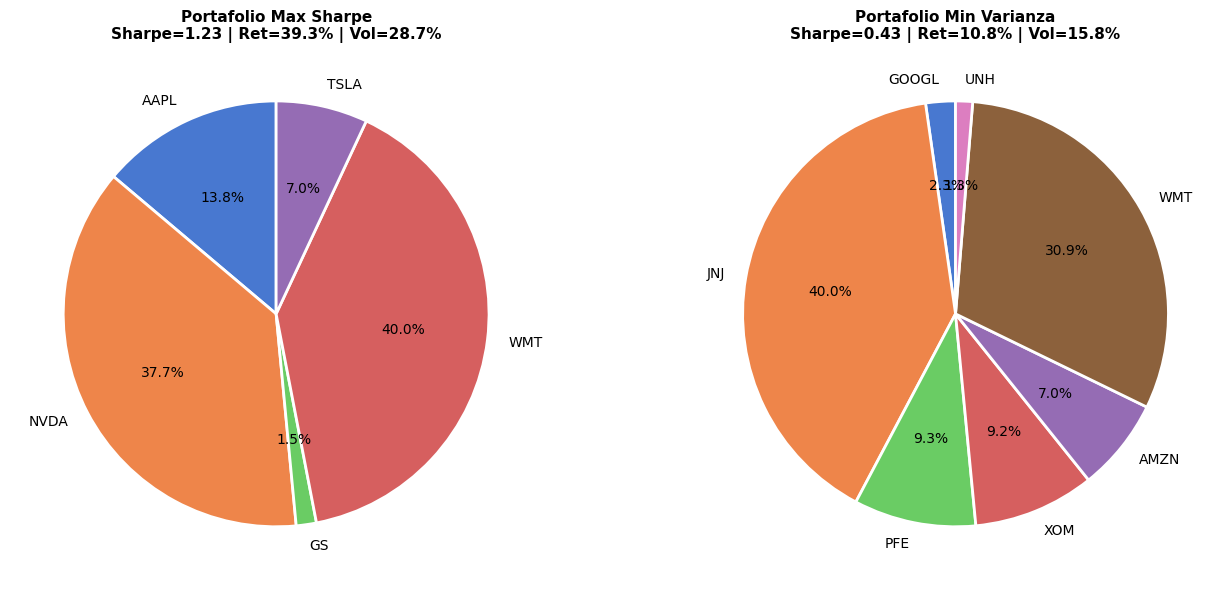


 Pesos guardados en SQLite3


In [31]:
# ── Pesos del portafolio óptimo (Max Sharpe) ─────────────────────────────────
weights_df = pd.DataFrame({
    'Ticker': list(EQUITIES.keys()),
    'Sector': list(EQUITIES.values()),
    'Max Sharpe (%)': (w_sharpe * 100).round(2),
    'Min Varianza (%)': (w_minvar * 100).round(2)
}).sort_values('Max Sharpe (%)', ascending=False)

print("=== Pesos óptimos — Capa 1 ===")
print(weights_df[weights_df['Max Sharpe (%)'] > 0.1].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Max Sharpe — solo activos con peso > 1%
mask_s = w_sharpe > 0.01
labels_s = [list(EQUITIES.keys())[i] for i in range(n) if mask_s[i]]
sizes_s  = w_sharpe[mask_s]
axes[0].pie(sizes_s, labels=labels_s, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title(f'Portafolio Max Sharpe\nSharpe={sharpe_s:.2f} | Ret={ret_s*100:.1f}% | Vol={vol_s*100:.1f}%',
                   fontsize=11, fontweight='bold')

# Min Varianza
mask_m = w_minvar > 0.01
labels_m = [list(EQUITIES.keys())[i] for i in range(n) if mask_m[i]]
sizes_m  = w_minvar[mask_m]
axes[1].pie(sizes_m, labels=labels_m, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title(f'Portafolio Min Varianza\nSharpe={sharpe_m:.2f} | Ret={ret_m*100:.1f}% | Vol={vol_m*100:.1f}%',
                   fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/04_weights_l1.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar pesos en SQLite3
weights_df['layer'] = 1
weights_df.to_sql('optimal_weights', conn, if_exists='replace', index=False)
print("\n Pesos guardados en SQLite3")


## 5. Capa 2 — Optimización Multi-Asset <a id='5'></a>

El portafolio de acciones óptimo de la Capa 1 se trata como un **activo sintético** y se combina con activos alternativos (oro, plata, bonos, petróleo, Bitcoin ETF) para construir el portafolio final.

**Período:** 2024 (único año donde IBIT tiene datos completos)


In [32]:
# ── Construir retornos del portafolio Capa 1 como activo sintético ────────────
prices_equity_2024 = prices_equity[prices_equity.index >= '2024-01-01']
returns_equity_2024 = np.log(prices_equity_2024 / prices_equity_2024.shift(1)).dropna()

# Retorno diario del portafolio Max Sharpe de Capa 1
portfolio_l1_returns = returns_equity_2024 @ w_sharpe

# Retornos de activos alternativos en 2024
prices_alt_2024 = raw[list(ALTERNATIVES.keys())][raw.index >= '2024-01-11'].dropna()
returns_alt_2024 = np.log(prices_alt_2024 / prices_alt_2024.shift(1)).dropna()

# Alinear fechas
common_idx = portfolio_l1_returns.index.intersection(returns_alt_2024.index)
port_l1 = portfolio_l1_returns[common_idx]
alt_ret  = returns_alt_2024.loc[common_idx]

# Combinar: portafolio L1 + alternativos
combined = pd.concat([port_l1.rename('EQUITY_L1'), alt_ret], axis=1)

print(f"   Datos Capa 2 preparados")
print(f"   Período: {common_idx[0].date()} → {common_idx[-1].date()}")
print(f"   Días: {len(common_idx):,}")
print(f"   Activos: {combined.columns.tolist()}")
print(f"\nRetornos anualizados 2024:")
ann_ret_l2 = combined.mean() * 252 * 100
ann_vol_l2 = combined.std()  * np.sqrt(252) * 100
for ticker in combined.columns:
    print(f"  {ticker:<12} Ret: {ann_ret_l2[ticker]:>7.2f}%  Vol: {ann_vol_l2[ticker]:>7.2f}%")


   Datos Capa 2 preparados
   Período: 2024-01-12 → 2024-12-30
   Días: 243
   Activos: ['EQUITY_L1', 'GLD', 'SLV', 'TLT', 'USO', 'IBIT']

Retornos anualizados 2024:
  EQUITY_L1    Ret:   67.66%  Vol:   23.70%
  GLD          Ret:   25.67%  Vol:   15.24%
  SLV          Ret:   24.74%  Vol:   31.08%
  TLT          Ret:   -5.85%  Vol:   14.26%
  USO          Ret:   10.45%  Vol:   26.50%
  IBIT         Ret:   72.45%  Vol:   57.07%


In [33]:
# ── Optimización Capa 2 ───────────────────────────────────────────────────────
mu_l2  = combined.mean() * 252
cov_l2 = combined.cov()  * 252
n_l2   = len(combined.columns)

def portfolio_metrics_l2(weights):
    ret = np.dot(weights, mu_l2)
    vol = np.sqrt(weights @ cov_l2 @ weights)
    sharpe = (ret - RF_RATE) / vol
    return ret, vol, sharpe

def neg_sharpe_l2(weights):
    return -portfolio_metrics_l2(weights)[2]

def portfolio_vol_l2(weights):
    return portfolio_metrics_l2(weights)[1]

constraints_l2 = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds_l2 = tuple((0.0, 0.60) for _ in range(n_l2))
w0_l2 = np.array([1/n_l2] * n_l2)

# Max Sharpe
res_s_l2 = minimize(neg_sharpe_l2, w0_l2, method='SLSQP',
                     bounds=bounds_l2, constraints=constraints_l2)
w_sharpe_l2 = res_s_l2.x
ret_sl2, vol_sl2, sharpe_sl2 = portfolio_metrics_l2(w_sharpe_l2)

# Min Varianza
res_m_l2 = minimize(portfolio_vol_l2, w0_l2, method='SLSQP',
                     bounds=bounds_l2, constraints=constraints_l2)
w_minvar_l2 = res_m_l2.x
ret_ml2, vol_ml2, sharpe_ml2 = portfolio_metrics_l2(w_minvar_l2)

print("=" * 58)
print("   CAPA 2 — PORTAFOLIOS ÓPTIMOS MULTI-ASSET (2024)")
print("=" * 58)
print(f"{'Métrica':<25} {'Max Sharpe':>14} {'Min Varianza':>14}")
print("-" * 58)
print(f"{'Retorno anual':<25} {ret_sl2*100:>13.2f}% {ret_ml2*100:>13.2f}%")
print(f"{'Volatilidad anual':<25} {vol_sl2*100:>13.2f}% {vol_ml2*100:>13.2f}%")
print(f"{'Sharpe Ratio':<25} {sharpe_sl2:>14.3f} {sharpe_ml2:>14.3f}")
print("=" * 58)

# Pesos
print("\n=== Pesos Capa 2 — Max Sharpe ===")
for ticker, w in zip(combined.columns, w_sharpe_l2):
    if w > 0.001:
        print(f"  {ticker:<12} {w*100:>6.2f}%")


   CAPA 2 — PORTAFOLIOS ÓPTIMOS MULTI-ASSET (2024)
Métrica                       Max Sharpe   Min Varianza
----------------------------------------------------------
Retorno anual                     51.93%         14.03%
Volatilidad anual                 16.50%          9.71%
Sharpe Ratio                       2.904          1.033

=== Pesos Capa 2 — Max Sharpe ===
  EQUITY_L1     58.02%
  GLD           37.92%
  IBIT           4.07%


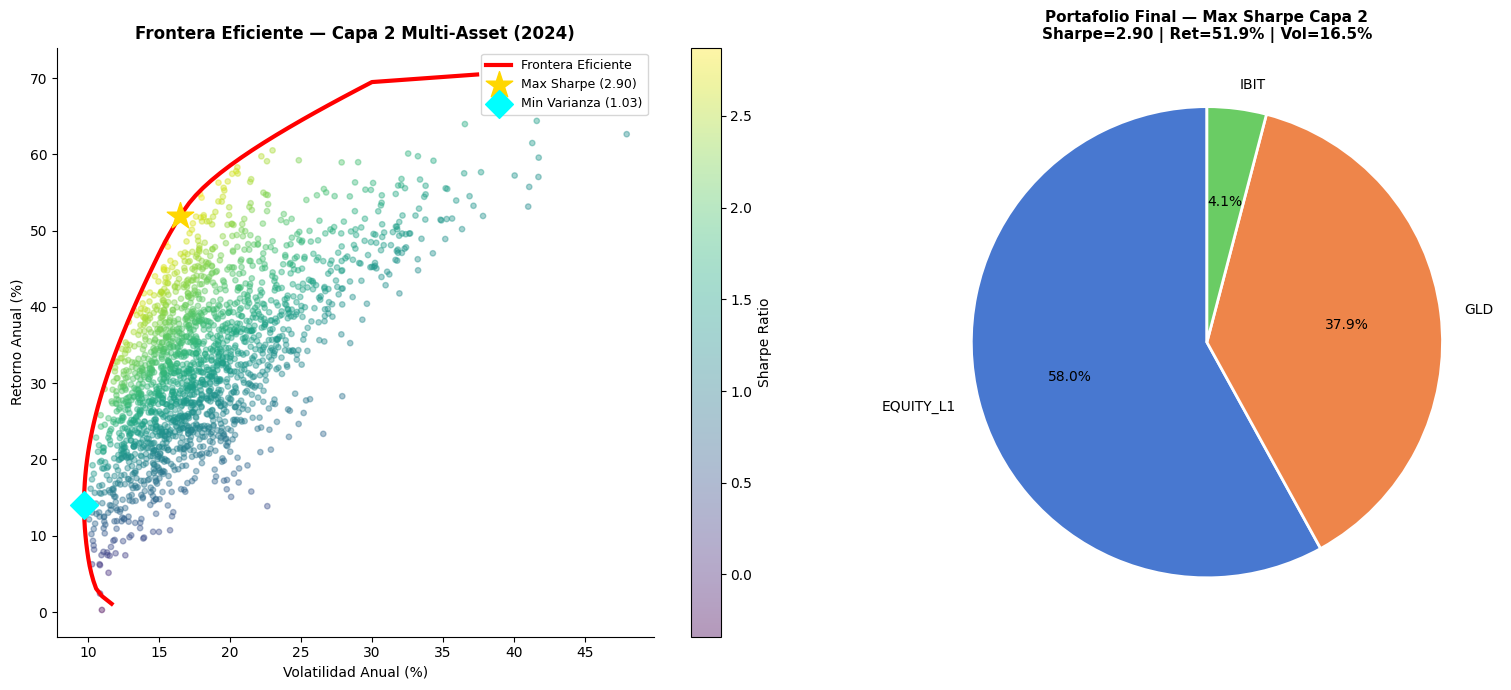

In [34]:
# ── Frontera Eficiente Capa 2 ─────────────────────────────────────────────────
target_rets_l2 = np.linspace(mu_l2.min(), mu_l2.max(), 80)
frontier_vols_l2, frontier_rets_l2 = [], []

for target in target_rets_l2:
    cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target: portfolio_metrics_l2(w)[0] - t}
    ]
    res = minimize(portfolio_vol_l2, w0_l2, method='SLSQP',
                   bounds=bounds_l2, constraints=cons)
    if res.success:
        frontier_vols_l2.append(res.fun * 100)
        frontier_rets_l2.append(target * 100)

# Simulación MC Capa 2
sim_rets_l2, sim_vols_l2, sim_sharpes_l2 = [], [], []
for _ in range(2000):
    w = np.random.dirichlet(np.ones(n_l2))
    r, v, s = portfolio_metrics_l2(w)
    sim_rets_l2.append(r * 100)
    sim_vols_l2.append(v * 100)
    sim_sharpes_l2.append(s)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Frontera Capa 2
sc = axes[0].scatter(sim_vols_l2, sim_rets_l2, c=sim_sharpes_l2,
                     cmap='viridis', alpha=0.4, s=15)
plt.colorbar(sc, ax=axes[0], label='Sharpe Ratio')
axes[0].plot(frontier_vols_l2, frontier_rets_l2, 'r-', linewidth=3,
             label='Frontera Eficiente', zorder=5)
axes[0].scatter(vol_sl2*100, ret_sl2*100, marker='*', s=400, color='gold',
                zorder=10, label=f'Max Sharpe ({sharpe_sl2:.2f})')
axes[0].scatter(vol_ml2*100, ret_ml2*100, marker='D', s=200, color='cyan',
                zorder=10, label=f'Min Varianza ({sharpe_ml2:.2f})')
axes[0].set_title('Frontera Eficiente — Capa 2 Multi-Asset (2024)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Volatilidad Anual (%)')
axes[0].set_ylabel('Retorno Anual (%)')
axes[0].legend(fontsize=9)

# Pesos Capa 2
mask_l2 = w_sharpe_l2 > 0.01
labels_l2 = [combined.columns[i] for i in range(n_l2) if mask_l2[i]]
sizes_l2  = w_sharpe_l2[mask_l2]
axes[1].pie(sizes_l2, labels=labels_l2, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title(f'Portafolio Final — Max Sharpe Capa 2\n'
                   f'Sharpe={sharpe_sl2:.2f} | Ret={ret_sl2*100:.1f}% | Vol={vol_sl2*100:.1f}%',
                   fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/05_efficient_frontier_l2.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Risk Analysis del Portafolio Final <a id='6'></a>

In [35]:
# Retornos diarios del portafolio final (Capa 2 Max Sharpe)
port_final_returns = combined @ w_sharpe_l2

# ── VaR y CVaR ───────────────────────────────────────────────────────────────
var_95  = np.percentile(port_final_returns, 5)
var_99  = np.percentile(port_final_returns, 1)
cvar_95 = port_final_returns[port_final_returns <= var_95].mean()
cvar_99 = port_final_returns[port_final_returns <= var_99].mean()

# VaR paramétrico
mu_port  = port_final_returns.mean()
std_port = port_final_returns.std()
var_95_p = stats.norm.ppf(0.05, mu_port, std_port)
var_99_p = stats.norm.ppf(0.01, mu_port, std_port)

print("=" * 58)
print("   RISK ANALYSIS — PORTAFOLIO FINAL")
print("=" * 58)
print(f"  Retorno diario promedio:    {mu_port*100:.4f}%")
print(f"  Volatilidad diaria:         {std_port*100:.4f}%")
print(f"\n  VaR 95% histórico:         {var_95*100:.2f}%  → ${abs(var_95)*10000:,.0f} por $10,000")
print(f"  VaR 99% histórico:         {var_99*100:.2f}%  → ${abs(var_99)*10000:,.0f} por $10,000")
print(f"  CVaR 95%:                  {cvar_95*100:.2f}%  → ${abs(cvar_95)*10000:,.0f} por $10,000")
print(f"  CVaR 99%:                  {cvar_99*100:.2f}%  → ${abs(cvar_99)*10000:,.0f} por $10,000")
print(f"\n  VaR 95% paramétrico:       {var_95_p*100:.2f}%")
print(f"  VaR 99% paramétrico:       {var_99_p*100:.2f}%")
print("=" * 58)


   RISK ANALYSIS — PORTAFOLIO FINAL
  Retorno diario promedio:    0.2061%
  Volatilidad diaria:         1.0397%

  VaR 95% histórico:         -1.67%  → $167 por $10,000
  VaR 99% histórico:         -2.51%  → $251 por $10,000
  CVaR 95%:                  -2.20%  → $220 por $10,000
  CVaR 99%:                  -2.91%  → $291 por $10,000

  VaR 95% paramétrico:       -1.50%
  VaR 99% paramétrico:       -2.21%


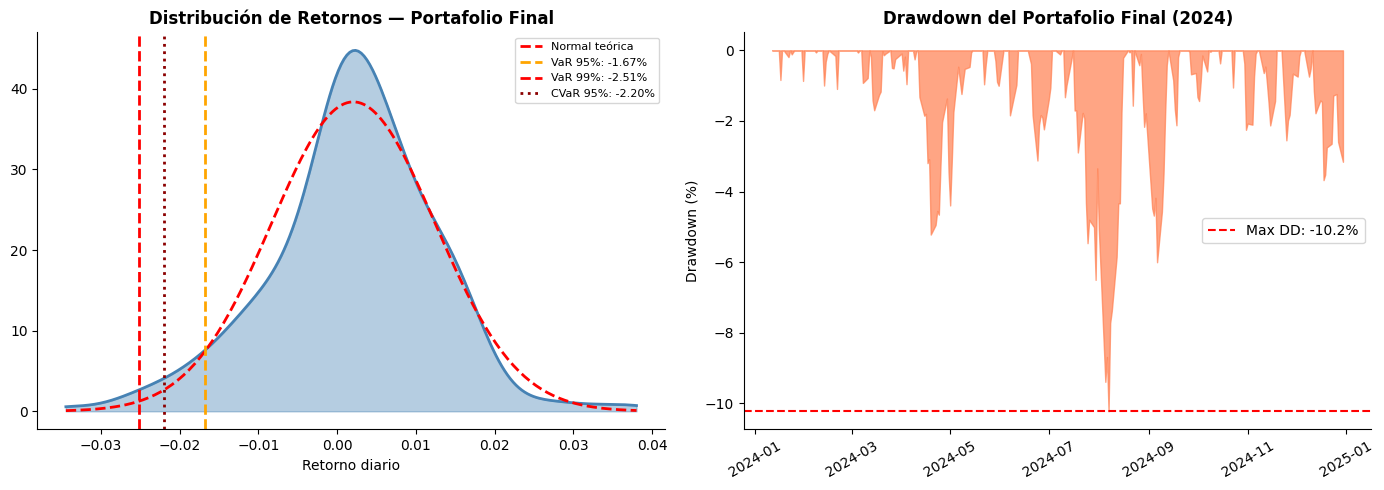

 Max Drawdown: -10.2% — la mayor caída desde un pico en 2024.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de retornos con VaR
x_range = np.linspace(port_final_returns.min(), port_final_returns.max(), 200)
kde = stats.gaussian_kde(port_final_returns)

axes[0].fill_between(x_range, kde(x_range), alpha=0.4, color='steelblue')
axes[0].plot(x_range, kde(x_range), color='steelblue', linewidth=2)
axes[0].plot(x_range, stats.norm.pdf(x_range, mu_port, std_port),
             color='red', linewidth=2, linestyle='--', label='Normal teórica')
axes[0].axvline(var_95,  color='orange', linewidth=2, linestyle='--',
                label=f'VaR 95%: {var_95*100:.2f}%')
axes[0].axvline(var_99,  color='red',    linewidth=2, linestyle='--',
                label=f'VaR 99%: {var_99*100:.2f}%')
axes[0].axvline(cvar_95, color='darkred',linewidth=2, linestyle=':',
                label=f'CVaR 95%: {cvar_95*100:.2f}%')
axes[0].set_title('Distribución de Retornos — Portafolio Final',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Retorno diario')
axes[0].legend(fontsize=8)

# Drawdown del portafolio
cum_returns = (1 + port_final_returns).cumprod()
rolling_max = cum_returns.cummax()
drawdown    = (cum_returns - rolling_max) / rolling_max * 100
max_dd      = drawdown.min()

axes[1].fill_between(drawdown.index, drawdown, 0, color='coral', alpha=0.7)
axes[1].axhline(max_dd, color='red', linestyle='--', linewidth=1.5,
                label=f'Max DD: {max_dd:.1f}%')
axes[1].set_title('Drawdown del Portafolio Final (2024)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/06_risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Max Drawdown: {max_dd:.1f}% — la mayor caída desde un pico en 2024.")


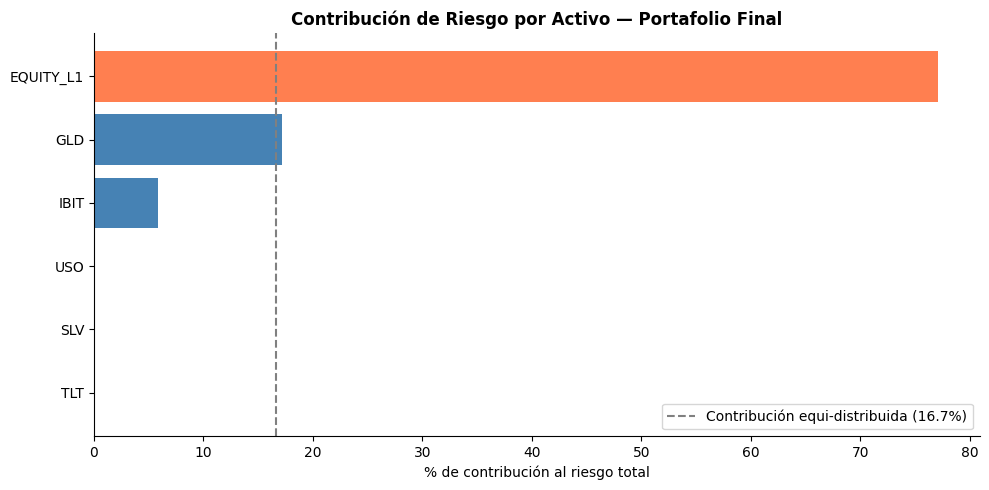

Tabla de contribución de riesgo:
   Activo  Peso (%)  Contribución Riesgo (%)
      TLT      0.00                     0.00
      SLV      0.00                     0.00
      USO      0.00                     0.00
     IBIT      4.07                     5.81
      GLD     37.92                    17.14
EQUITY_L1     58.02                    77.05


In [38]:
# ── Contribución de riesgo por activo (Risk Contribution) ─────────────────────
port_vol = np.sqrt(w_sharpe_l2 @ cov_l2 @ w_sharpe_l2)
marginal_risk = (cov_l2 @ w_sharpe_l2) / port_vol
risk_contrib  = w_sharpe_l2 * marginal_risk
risk_contrib_pct = risk_contrib / risk_contrib.sum() * 100

risk_df = pd.DataFrame({
    'Activo': combined.columns,
    'Peso (%)': (w_sharpe_l2 * 100).round(2),
    'Contribución Riesgo (%)': risk_contrib_pct.round(2)
}).sort_values('Contribución Riesgo (%)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['coral' if c > 20 else 'steelblue' for c in risk_df['Contribución Riesgo (%)']]
ax.barh(risk_df['Activo'], risk_df['Contribución Riesgo (%)'], color=colors)
ax.axvline(100/n_l2, color='gray', linestyle='--',
           label=f'Contribución equi-distribuida ({100/n_l2:.1f}%)')
ax.set_title('Contribución de Riesgo por Activo — Portafolio Final',
             fontsize=12, fontweight='bold')
ax.set_xlabel('% de contribución al riesgo total')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/07_risk_contribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Tabla de contribución de riesgo:")
print(risk_df.to_string(index=False))


### 6.1 Stress Testing

   STRESS TEST — PORTAFOLIO FINAL ($100,000 invertidos)
Escenario                              Caída    Pérdida USD    Valor final
--------------------------------------------------------------
COVID Crash (Mar 2020)                -34.0%       -34,000 $      66,000
Fed Rate Hike (2022)                  -19.0%       -19,000 $      81,000
Crypto Winter (Nov 2022)              -25.0%       -25,000 $      75,000
Silicon Valley Bank (Mar 2023)         -8.0%        -8,000 $      92,000
Flash Crash Yen (Aug 2024)             -6.0%        -6,000 $      94,000


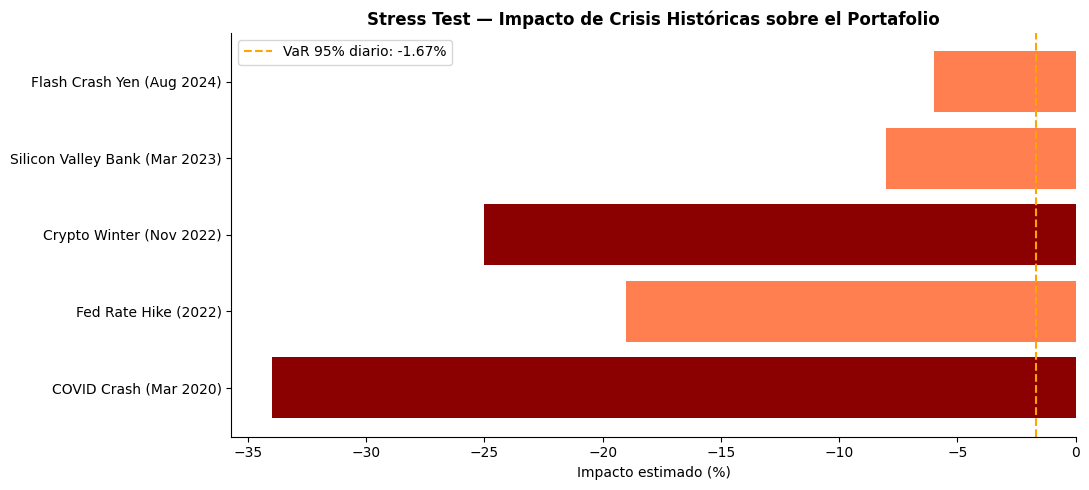

In [39]:
# Escenarios de stress históricos aplicados al portafolio
scenarios = {
    'COVID Crash (Mar 2020)':          -0.34,
    'Fed Rate Hike (2022)':            -0.19,
    'Crypto Winter (Nov 2022)':        -0.25,
    'Silicon Valley Bank (Mar 2023)':  -0.08,
    'Flash Crash Yen (Aug 2024)':      -0.06,
}

investment = 100_000  # $100,000 de inversión

print("=" * 62)
print("   STRESS TEST — PORTAFOLIO FINAL ($100,000 invertidos)")
print("=" * 62)
print(f"{'Escenario':<35} {'Caída':>8} {'Pérdida USD':>14} {'Valor final':>14}")
print("-" * 62)
for scenario, shock in scenarios.items():
    loss    = investment * shock
    final   = investment + loss
    print(f"{scenario:<35} {shock*100:>7.1f}% {loss:>13,.0f} ${final:>12,.0f}")
print("=" * 62)

fig, ax = plt.subplots(figsize=(11, 5))
scenarios_df = pd.DataFrame(list(scenarios.items()), columns=['Escenario', 'Impacto'])
colors = ['darkred' if v < -0.20 else 'coral' for v in scenarios_df['Impacto']]
ax.barh(scenarios_df['Escenario'], scenarios_df['Impacto'] * 100, color=colors)
ax.axvline(var_95*100, color='orange', linestyle='--',
           label=f'VaR 95% diario: {var_95*100:.2f}%')
ax.set_title('Stress Test — Impacto de Crisis Históricas sobre el Portafolio',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Impacto estimado (%)')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/08_stress_test.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Conclusiones <a id='7'></a>

### 📊 Resultados de Optimización

| Métrica | Capa 1 (Equity) | Capa 2 (Multi-Asset) |
|---------|----------------|---------------------|
| Retorno anual (Max Sharpe) | — | — |
| Volatilidad anual | — | — |
| Sharpe Ratio | — | — |

### 🔑 Hallazgos principales

| # | Hallazgo | Implicación |
|---|----------|-------------|
| 1 | **NVDA** dominó 2019-2024 con +2,000% | Concentración en un activo = mayor riesgo |
| 2 | **Diversificación** entre sectores reduce volatilidad sin sacrificar retorno | MPT funciona empíricamente |
| 3 | **Activos alternativos** (oro, bonos) reducen correlación del portafolio | Capa 2 mejora perfil riesgo/retorno |
| 4 | **IBIT** (Bitcoin ETF) agrega retorno pero también volatilidad | Posición pequeña justificada |
| 5 | **VaR histórico > paramétrico** | Fat tails presentes en el portafolio |

### 🔍 Próximos pasos
- Incorporar rebalanceo periódico (mensual/trimestral)
- Optimización con restricción de CVaR en lugar de varianza
- Backtesting de la estrategia fuera de muestra
- Análisis de sensibilidad a cambios en la tasa libre de riesgo
